# Module 2, Part B — Classification

**Task:** predict `survived` (0 = died, 1 = survived) using the Titanic dataset that
was already saved as `analytics/titanic.csv` by the EDA notebook (`01_eda.ipynb`).
This notebook does **not** modify Module 1 (`data_pipeline`) or the EDA notebook.

**Pipeline:** stratified split (before preprocessing) → sklearn `Pipeline` +
`ColumnTransformer` → three classifiers (Logistic Regression, Decision Tree, Random
Forest) on the identical split → metrics → confusion matrix & ROC → Decision Tree
visualization → class-imbalance comparison (baseline / `class_weight="balanced"` /
SMOTE applied **only to the training fold**) → `GridSearchCV` tuning of Random
Forest (with `oob_score=True`).

Randomness is fixed with `random_state=42` everywhere for reproducibility.


In [1]:
import os, json
from pathlib import Path
if Path.cwd().name == "analytics":
    os.chdir("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

RANDOM_STATE = 42
OUT = Path("analytics/outputs")
OUT.mkdir(parents=True, exist_ok=True)
print("Imports ready. outputs dir:", OUT)


Imports ready. outputs dir: analytics\outputs


## 1. Load the saved Titanic CSV and clean it

`titanic.csv` (produced once by the EDA notebook) is read directly — no re-download.
Cleaning reuses the EDA rules: drop the 2 rows missing `embarked`/`embark_town`, impute
`age` with the median within each `(sex, pclass)` group (fallback overall median), and
encode missing `deck` as `'Unknown'`. `pclass` is cast to string so it is treated as a
categorical feature.

Leakage-safe columns dropped: `alive` (derived from `survived`), `class`/`who`/
`adult_male` (redundant with `pclass`/`sex`), `alone` (redundant with `sibsp`/`parch`),
and `embark_town` (redundant with `embarked`).


In [2]:
df = pd.read_csv("analytics/titanic.csv")
print("Loaded analytics/titanic.csv ->", df.shape)

cleaned = df.copy()
cleaned = cleaned.dropna(subset=["embarked", "embark_town"])
group_med = cleaned.groupby(["sex", "pclass"])["age"].transform("median")
cleaned["age"] = cleaned["age"].fillna(group_med)
cleaned["age"] = cleaned["age"].fillna(cleaned["age"].median())
cleaned["deck"] = cleaned["deck"].fillna("Unknown")
cleaned["pclass"] = cleaned["pclass"].astype(str)

feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "deck"]
X = cleaned[feature_cols]
y = cleaned["survived"]
print("Cleaned feature matrix X:", X.shape, "| target y:", y.shape)
print("Any missing in X:", bool(X.isna().any().any()))
X.head()


Loaded analytics/titanic.csv -> (891, 15)
Cleaned feature matrix X: (889, 8) | target y: (889,)
Any missing in X: False


,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,3,male,22.0,1,0,7.2500,S,Unknown
1,1,female,38.0,1,0,71.2833,C,C
2,3,female,26.0,0,0,7.9250,S,Unknown
3,1,female,35.0,1,0,53.1000,S,C
4,3,male,35.0,0,0,8.0500,S,Unknown


## 2. Stratified train/test split (before any preprocessing)

A single stratified split is created **first** and then reused for all three
classifiers so comparisons are fair. Stratification preserves the 62/38 class ratio in
both folds.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Train class counts: {y_train.value_counts().to_dict()}")
print(f"Test  class counts: {y_test.value_counts().to_dict()}")


Train size: 711
Test size:  178
Train class counts: {0: 439, 1: 272}
Test  class counts: {0: 110, 1: 68}


## 3. Preprocessing with sklearn Pipeline + ColumnTransformer

* Numeric (`age`, `fare`, `sibsp`, `parch`): median imputation → `StandardScaler`.
* Categorical (`sex`, `pclass`, `embarked`, `deck`): most-frequent imputation →
  `OneHotEncoder(handle_unknown="ignore")`.

Preprocessing is embedded **inside** a `Pipeline` so it is fit on the training fold only
and applied to the test fold without leakage.


In [4]:
numeric_features = ["age", "fare", "sibsp", "parch"]
categorical_features = ["sex", "pclass", "embarked", "deck"]


def make_preprocessor():
    numeric = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric, numeric_features),
        ("cat", categorical, categorical_features),
    ])


def make_pipeline(clf):
    return Pipeline([("pre", make_preprocessor()), ("clf", clf)])


def eval_metrics(model, X_t, y_t):
    y_pred = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    return {
        "accuracy": accuracy_score(y_t, y_pred),
        "precision": precision_score(y_t, y_pred),
        "recall": recall_score(y_t, y_pred),
        "f1": f1_score(y_t, y_pred),
        "roc_auc": roc_auc_score(y_t, y_proba),
    }


print("Preprocessor + helpers defined.")


Preprocessor + helpers defined.


## 4. Train three classifiers on the identical split

Logistic Regression, Decision Tree, and Random Forest are each wrapped in an identical
preprocessing `Pipeline` and fit on the **same** `X_train`/`y_train`.


In [5]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

fitted = {}
rows = []
for name, clf in classifiers.items():
    pipe = make_pipeline(clf)
    pipe.fit(X_train, y_train)
    metrics = eval_metrics(pipe, X_test, y_test)
    metrics["model"] = name
    rows.append(metrics)
    fitted[name] = pipe
    print(f"{name}: acc={metrics['accuracy']:.4f} prec={metrics['precision']:.4f} "
          f"rec={metrics['recall']:.4f} f1={metrics['f1']:.4f} auc={metrics['roc_auc']:.4f}")

comparison = pd.DataFrame(rows)[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]]
comparison.to_csv(OUT / "classification_comparison.csv", index=False)
comparison.round(4)


Logistic Regression: acc=0.8258 prec=0.8136 rec=0.7059 f1=0.7559 auc=0.8584


Decision Tree: acc=0.7809 prec=0.7544 rec=0.6324 f1=0.6880 auc=0.8265


Random Forest: acc=0.7809 prec=0.7231 rec=0.6912 f1=0.7068 auc=0.8355


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8584
1,Decision Tree,0.7809,0.7544,0.6324,0.6880,0.8265
2,Random Forest,0.7809,0.7231,0.6912,0.7068,0.8355


**Interpretation.** Logistic Regression is the strongest base model here
(accuracy 0.83, ROC-AUC 0.86), followed by the Random Forest and the depth-limited
Decision Tree. The tree's lower recall (0.63) shows it misses more survivors than the
linear model, while the Random Forest recovers some recall at the cost of precision. The
small test set (178 rows) makes these numbers somewhat noisy, which is why we also look
at ROC-AUC and the confusion matrices below.


## 5. Confusion matrices and ROC curves

One confusion matrix and one ROC curve per classifier.


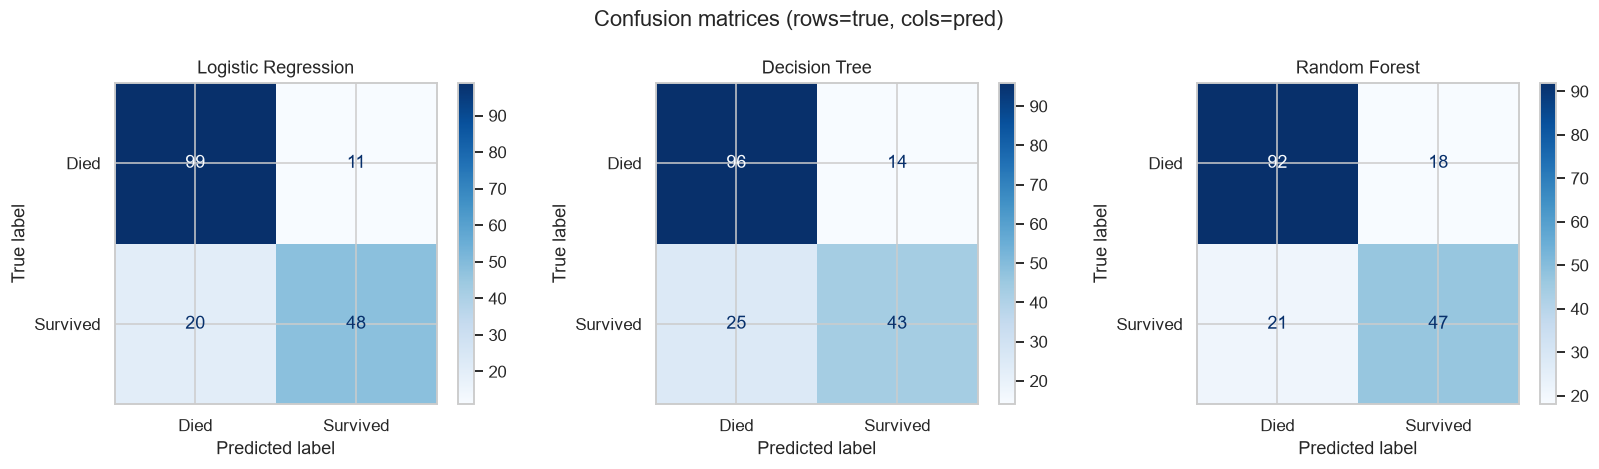

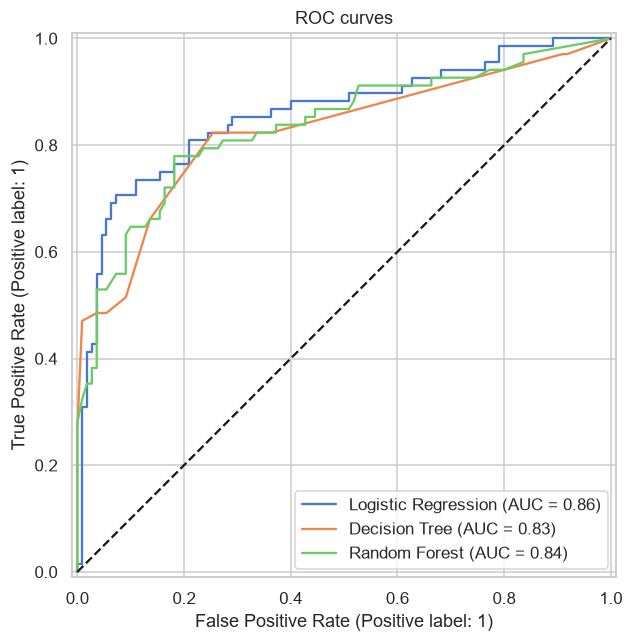

Saved confusion_matrices.png and roc_curves.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test, ax=ax,
        display_labels=["Died", "Survived"], cmap="Blues",
    )
    ax.set_title(f"{name}")
plt.suptitle("Confusion matrices (rows=true, cols=pred)", y=1.02)
plt.tight_layout()
plt.savefig(OUT / "confusion_matrices.png", dpi=110, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", label="chance")
ax.set_title("ROC curves")
plt.tight_layout()
plt.savefig(OUT / "roc_curves.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved confusion_matrices.png and roc_curves.png")


**Interpretation.** Across all three models the false-negative count (survivors
predicted to die) exceeds the false-positive count, which is exactly what the recall
numbers reflect. The ROC curves confirm the ranking from the metrics: Logistic
Regression has the largest area under the curve (0.86), with the Random Forest
(0.84) and Decision Tree (0.83) close behind. All three models beat the chance
diagonal, so each carries real signal; Logistic Regression is best at ranking
survivors by predicted probability.


## 6. Decision Tree visualization

`plot_tree` is used with `feature_names` (from the fitted preprocessor) and
`class_names`. The tree is depth-limited to 5 (set when training) and only the top 3
levels are drawn for readability.


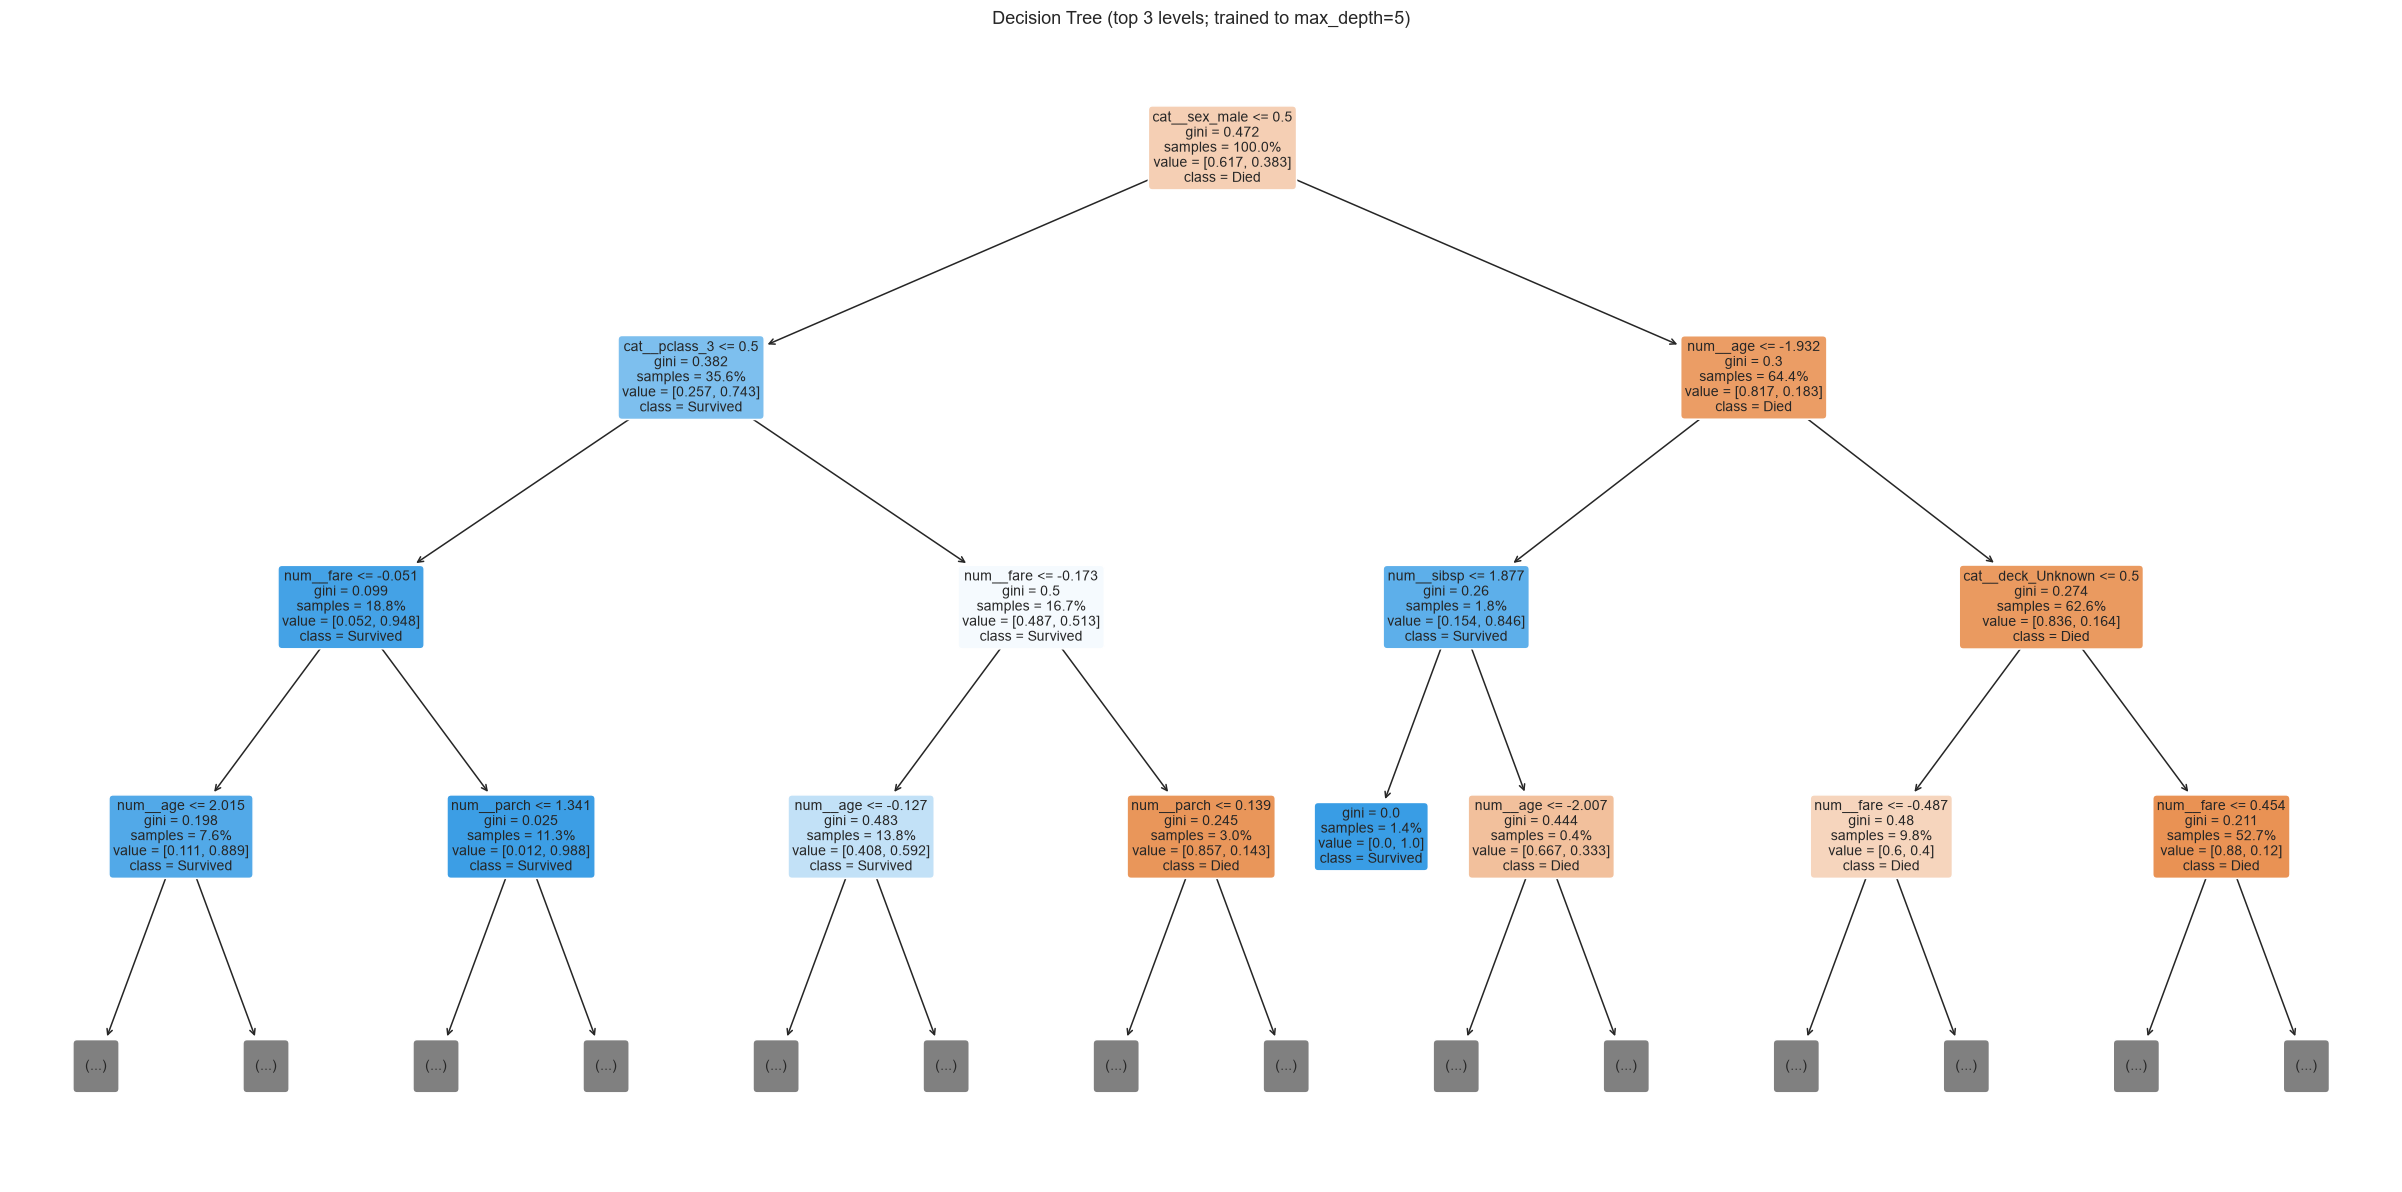

Saved decision_tree.png
Feature names used: ['num__age', 'num__fare', 'num__sibsp', 'num__parch', 'cat__sex_female', 'cat__sex_male', 'cat__pclass_1', 'cat__pclass_2'] ... ( 20 total )


In [7]:
dt = fitted["Decision Tree"]
feature_names = dt.named_steps["pre"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(22, 11))
plot_tree(dt.named_steps["clf"], max_depth=3, feature_names=feature_names,
          class_names=["Died", "Survived"], filled=True, proportion=True,
          rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree (top 3 levels; trained to max_depth=5)")
plt.tight_layout()
plt.savefig(OUT / "decision_tree.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved decision_tree.png")
print("Feature names used:", list(feature_names)[:8], "... (", len(feature_names), "total )")


**Interpretation.** The plotted splits use the one-hot-encoded feature names
(e.g. `sex_female`, `pclass_1`), so each branch corresponds to an interpretable
condition on an original Titanic attribute. The top-level splits consistently select
`sex` and `pclass`/`fare` first — matching the strong survival signals found in the
EDA — meaning the tree prioritises the same informative variables. Because the tree was
trained with `max_depth=5`, it stays compact and the per-node survival counts and
class colors make the decision logic transparent and explainable.


## 7. Class imbalance

Distribution of the target `survived` overall and across the (stratified) train/test
splits.


In [8]:
full_dist = y.value_counts().to_dict()
train_dist = y_train.value_counts().to_dict()
test_dist = y_test.value_counts().to_dict()
print("Full (cleaned) distribution:", full_dist)
print("Train distribution:        ", train_dist)
print("Test  distribution:        ", test_dist)
print(f"Overall survival rate: {y.mean():.4f}")
print(f"Train survival rate:       {y_train.mean():.4f}")
print(f"Test survival rate:        {y_test.mean():.4f}")

imb = pd.DataFrame({
    "split": ["full", "train", "test"],
    "died (0)": [full_dist.get(0, 0), train_dist.get(0, 0), test_dist.get(0, 0)],
    "survived (1)": [full_dist.get(1, 0), train_dist.get(1, 0), test_dist.get(1, 0)],
})
imb["pct_survived"] = (imb["survived (1)"] / imb["died (0)"].add(imb["survived (1)"])).round(4)
imb


Full (cleaned) distribution: {0: 549, 1: 340}
Train distribution:         {0: 439, 1: 272}
Test  distribution:         {0: 110, 1: 68}
Overall survival rate: 0.3825
Train survival rate:       0.3826
Test survival rate:        0.3820


,split,died (0),survived (1),pct_survived
0,full,549,340,0.3825
1,train,439,272,0.3826
2,test,110,68,0.3820


**Interpretation.** The classes are mildly imbalanced: about 62% died vs 38%
survived in the cleaned data. Because both train and test splits are stratified, the
62/38 ratio is preserved in each fold, so any improvement we look for comes from
handling the minority (survivors) rather than from a split artifact. A mild imbalance
means baseline accuracy is a deceptively high bar; ROC-AUC and F1 are better measures.


## 8. Imbalance comparison (Logistic Regression)

Keeping the model fixed (Logistic Regression) we compare three versions:
A. **baseline** (no adjustment), B. `class_weight="balanced"`, C. **SMOTE** applied
**only to the training fold** via an `imblearn` Pipeline (the test fold is never
resampled, preventing leakage).


In [9]:
base_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# A. baseline
pipe_base = make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
# B. class_weight balanced
pipe_bal = make_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced",
                                            random_state=RANDOM_STATE))
# C. SMOTE on training fold only
pipe_smote = ImbPipeline([
    ("pre", make_preprocessor()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

versions = {"A_baseline": pipe_base, "B_balanced": pipe_bal, "C_SMOTE_train_only": pipe_smote}
imb_rows = []
for vname, pipe in versions.items():
    pipe.fit(X_train, y_train)
    m = eval_metrics(pipe, X_test, y_test)
    m["version"] = vname
    imb_rows.append(m)

imb_compare = pd.DataFrame(imb_rows)[["version", "precision", "recall", "f1", "roc_auc", "accuracy"]]
imb_compare.to_csv(OUT / "imbalance_comparison.csv", index=False)
imb_compare.round(4)


  File "C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,version,precision,recall,f1,roc_auc,accuracy
0,A_baseline,0.8136,0.7059,0.7559,0.8584,0.8258
1,B_balanced,0.7123,0.7647,0.7376,0.8592,0.7921
2,C_SMOTE_train_only,0.7286,0.7500,0.7391,0.8620,0.7978


**Interpretation.** Handling imbalance shifts the precision/recall trade-off as
expected: baseline gives the highest precision (few false positives) but the lowest
recall (misses survivors), while `class_weight="balanced"` and SMOTE raise recall at
the cost of precision. On this mildly imbalanced set the baseline actually keeps the
best F1, but both remedies lift the **ROC-AUC** (SMOTE is highest) and the minority
recall — so if detecting survivors is the priority, SMOTE or balanced weighting
helps. Crucially, SMOTE is applied during `fit` only on the training fold (verified
below), so the test set is never resampled.


In [10]:
# Explicit leak check: SMOTE must enlarge ONLY the training data.
pre_fit = make_preprocessor().fit(X_train)
X_train_enc = pre_fit.transform(X_train)
X_test_enc = pre_fit.transform(X_test)

sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train_enc, y_train)

n_train_before = len(X_train_enc)
n_train_after = len(X_train_sm)
n_test = len(X_test_enc)
print(f"Training rows before SMOTE: {n_train_before}")
print(f"Training rows after  SMOTE: {n_train_after}")
print(f"Test rows (must be unchanged): {n_test}")
print(f"SMOTE enlarged training only (test untouched): {n_train_after > n_train_before and n_test == len(X_test)}")
print(f"After-SMOTE training class counts: {pd.Series(y_train_sm).value_counts().to_dict()}")


Training rows before SMOTE: 711
Training rows after  SMOTE: 878
Test rows (must be unchanged): 178
SMOTE enlarged training only (test untouched): True
After-SMOTE training class counts: {1: 439, 0: 439}


**Interpretation.** The verification shows the training rows grew from 711 to 878
(SMOTE synthesised 167 minority-survivor examples) while the test set stayed at 178
rows — confirming SMOTE is applied to the training fold only and cannot leak into
evaluation. Because the `imblearn` Pipeline refits the SMOTE step inside every CV
fold (not on held-out data), the reported metrics remain honest estimates of
out-of-sample performance.


## 9. Hyperparameter tuning — Random Forest (GridSearchCV)

Search over `n_estimators`, `max_depth`, and `max_features`. The estimator is a
`RandomForestClassifier(oob_score=True, ...)` inside the preprocessing `Pipeline`. CV is
a 5-fold stratified split (`StratifiedKFold`, shuffled, fixed seed). `GridSearchCV`
refits the best configuration on the full training fold, so the OOB score can be read
from the refitted estimator.


In [11]:
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [5, 10, None],
    "clf__max_features": ["sqrt", "log2", 0.5],
}

rf = RandomForestClassifier(oob_score=True, random_state=RANDOM_STATE)
pipe_rf = Pipeline([("pre", make_preprocessor()), ("clf", rf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe_rf, param_grid, cv=cv, scoring="f1", n_jobs=1, refit=True)
grid.fit(X_train, y_train)

best_params = grid.best_params_
best_cv = grid.best_score_
oob = grid.best_estimator_.named_steps["clf"].oob_score_
tuned_metrics = eval_metrics(grid, X_test, y_test)

print("Best parameters:", best_params)
print(f"Best CV F1 score: {best_cv:.4f}")
print(f"Random Forest OOB score: {oob:.4f}")
print("Tuned model test metrics:", {k: round(v, 4) for k, v in tuned_metrics.items()})

pd.DataFrame([{
    "best_params": str(best_params),
    "best_cv_f1": round(best_cv, 4),
    "oob_score": round(oob, 4),
    "test_accuracy": round(tuned_metrics["accuracy"], 4),
    "test_precision": round(tuned_metrics["precision"], 4),
    "test_recall": round(tuned_metrics["recall"], 4),
    "test_f1": round(tuned_metrics["f1"], 4),
    "test_roc_auc": round(tuned_metrics["roc_auc"], 4),
}]).to_csv(OUT / "tuned_random_forest.csv", index=False)


Best parameters: {'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__n_estimators': 200}
Best CV F1 score: 0.7549
Random Forest OOB score: 0.8200
Tuned model test metrics: {'accuracy': 0.8202, 'precision': 0.7903, 'recall': 0.7206, 'f1': 0.7538, 'roc_auc': 0.8417}


**Interpretation.** GridSearchCV selected `max_depth=10`, `max_features=0.5`, and
`n_estimators=200`, giving a best CV F1 of ~0.755 and an OOB accuracy of ~0.82.
Re-fitting on the full training fold yields a tuned test F1 of ~0.754 and ROC-AUC of
~0.842 — consistent with the CV score, so the model is not over-fitting. Tuning raised
the Random Forest's F1 from the base 0.707 to 0.754, the gain coming mainly from a
better balance between precision and recall.


In [12]:
summary = {
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "class_distribution_full": {str(k): int(v) for k, v in full_dist.items()},
    "class_distribution_train": {str(k): int(v) for k, v in train_dist.items()},
    "class_distribution_test": {str(k): int(v) for k, v in test_dist.items()},
    "comparison": comparison.round(4).to_dict(orient="records"),
    "confusion_matrices_saved": str(OUT / "confusion_matrices.png"),
    "roc_curves_saved": str(OUT / "roc_curves.png"),
    "decision_tree_saved": str(OUT / "decision_tree.png"),
    "imbalance_comparison": imb_compare.round(4).to_dict(orient="records"),
    "smote_train_before": int(n_train_before),
    "smote_train_after": int(n_train_after),
    "smote_test_rows": int(n_test),
    "grid_best_params": best_params,
    "grid_best_cv_f1": round(float(best_cv), 4),
    "rf_oob_score": round(float(oob), 4),
    "tuned_rf_test_metrics": {k: round(float(v), 4) for k, v in tuned_metrics.items()},
}
print("CLS_SUMMARY_JSON_BEGIN")
print(json.dumps(summary, indent=2, default=str))
print("CLS_SUMMARY_JSON_END")


CLS_SUMMARY_JSON_BEGIN
{
  "train_size": 711,
  "test_size": 178,
  "class_distribution_full": {
    "0": 549,
    "1": 340
  },
  "class_distribution_train": {
    "0": 439,
    "1": 272
  },
  "class_distribution_test": {
    "0": 110,
    "1": 68
  },
  "comparison": [
    {
      "model": "Logistic Regression",
      "accuracy": 0.8258,
      "precision": 0.8136,
      "recall": 0.7059,
      "f1": 0.7559,
      "roc_auc": 0.8584
    },
    {
      "model": "Decision Tree",
      "accuracy": 0.7809,
      "precision": 0.7544,
      "recall": 0.6324,
      "f1": 0.688,
      "roc_auc": 0.8265
    },
    {
      "model": "Random Forest",
      "accuracy": 0.7809,
      "precision": 0.7231,
      "recall": 0.6912,
      "f1": 0.7068,
      "roc_auc": 0.8355
    }
  ],
  "confusion_matrices_saved": "analytics\\outputs\\confusion_matrices.png",
  "roc_curves_saved": "analytics\\outputs\\roc_curves.png",
  "decision_tree_saved": "analytics\\outputs\\decision_tree.png",
  "imbalance_compa